In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from site import addsitepackages

addsitepackages(None)

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from yggdrasil.data.etl.spark.init import get_spark_session
from yggdrasil.core.dtypes.dataset import TableSpec
from yggdrasil.core.dtypes.options import DatasetOptions, PreprocessingOptions
from yggdrasil.data.data_extractor.mnist import MNISTDataExtractor
from yggdrasil.data.datamodules.mnist import MNISTDataModule
from yggdrasil.core.dtypes.classification.base import MulticlassPreprocessedInput

INFO:yggdrasil.core.dataclasses:USE_VANILLA_DATACLASS: False
INFO:yggdrasil.core.dataclasses:ARBITRARY_TYPES_ALLOWED: True
INFO:datasets:PyTorch version 2.3.1 available.


In [4]:
example_datamodule = MNISTDataModule(
    input_table_spec=TableSpec(
        table_identifier="mnist_784",
        train_table_sample=80.0,
        eval_table_sample=10.0,
        test_table_sample=10.0,
    ),
    data_extractor=MNISTDataExtractor(),
    dataset_options=DatasetOptions(num_proc=10, streaming=True),
    features_preprocessing_options=PreprocessingOptions(nsamples=100),
)

In [5]:
example_datamodule.prepare_data()
example_datamodule.setup()

25/06/17 20:40:34 WARN Utils: Your hostname, MacBook-Pro-Kasan.local resolves to a loopback address: 127.0.0.1; using 192.168.1.18 instead (on interface en0)
25/06/17 20:40:34 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/17 20:40:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
INFO:yggdrasil.preprocessing.normalization:Extracting normalization for feature: 0
INFO:yggdrasil.preprocessing.normalization:Feature 0 normalization NormalizationParams(ftype=<Ftype.BINARY: 'binary'>, boxcox_lambda=None, boxcox_shift=0.0, mean=0.0, stdev=1.0, possible_values=None, quantiles=None, min_value=0.0, max_value=0.0)
INFO:yggdrasil.preprocessing.normalization:Extracting normalization for feature: 1
INFO:yggdrasil.preprocessing.normalization:Feature 1 normalization No

In [6]:
batch: MulticlassPreprocessedInput = next(iter(example_datamodule.train_dataloader()))
print(batch.size())

MulticlassPreprocessedInput(target=torch.Size([1024, 1]), features=Feature(dense_features=torch.Size([1024, 2008])), nclasses=10, extras=ExtraData(sample_id=torch.Size([1024])))


In [7]:
assert example_datamodule.train_data is not None
assert example_datamodule.eval_data is not None
assert example_datamodule.test_data is not None

print(example_datamodule.train_data)
print(example_datamodule.eval_data)
print(example_datamodule.test_data)

ParquetDataset(dataset_url='file:///Users/juicefv/project_template/notebooks/mnist/spark-warehouse/tmp_parquet_ntrbmulfii')
ParquetDataset(dataset_url='file:///Users/juicefv/project_template/notebooks/mnist/spark-warehouse/tmp_parquet_wjgyjafwzj')
ParquetDataset(dataset_url='file:///Users/juicefv/project_template/notebooks/mnist/spark-warehouse/tmp_parquet_intaadedlz')


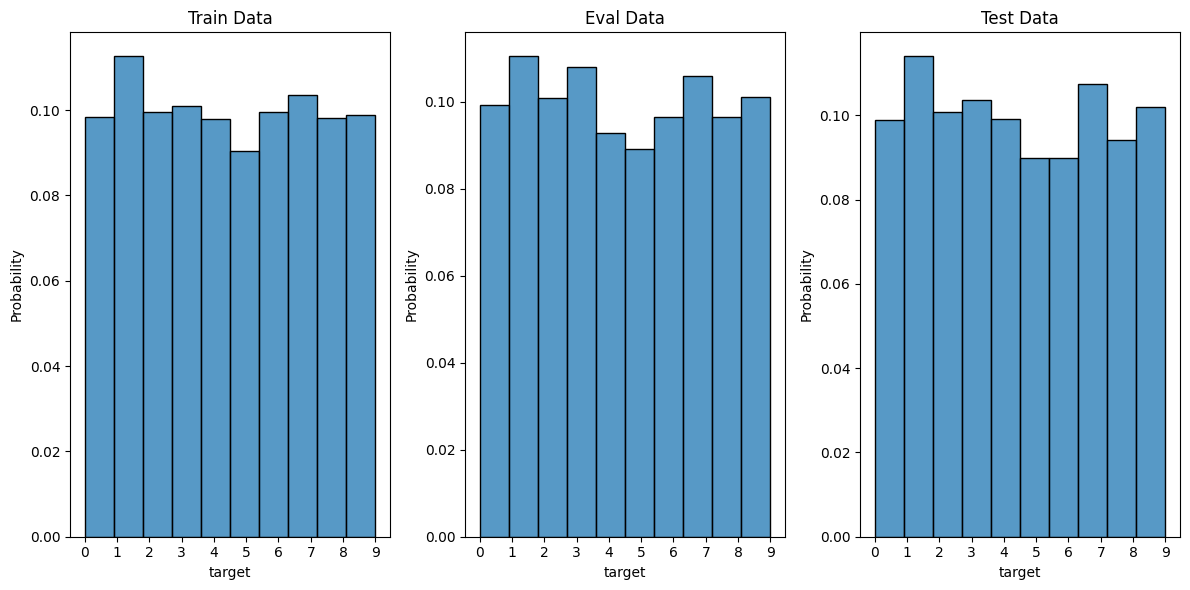

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

assert example_datamodule.train_data is not None
assert example_datamodule.eval_data is not None
assert example_datamodule.test_data is not None

train_target = pd.read_parquet(example_datamodule.train_data.dataset_url, columns=["target"])
eval_target = pd.read_parquet(example_datamodule.eval_data.dataset_url, columns=["target"])
test_target = pd.read_parquet(example_datamodule.test_data.dataset_url, columns=["target"])
sns.histplot(train_target, x="target", bins=10, stat="probability", ax=ax[0])
ax[0].set_title("Train Data")
ax[0].set_xticks(range(10))
sns.histplot(eval_target, x="target", bins=10, stat="probability", ax=ax[1])
ax[1].set_title("Eval Data")
ax[1].set_xticks(range(10))
sns.histplot(test_target, x="target", bins=10, stat="probability", ax=ax[2])
ax[2].set_title("Test Data")
ax[2].set_xticks(range(10))
plt.tight_layout()

In [9]:
assert example_datamodule.train_data is not None
assert example_datamodule.eval_data is not None
assert example_datamodule.test_data is not None

spark = get_spark_session()
spark.sql(f"DROP TABLE IF EXISTS {example_datamodule.train_data.dataset_url.split('/')[-1]}")
spark.sql(f"DROP TABLE IF EXISTS {example_datamodule.eval_data.dataset_url.split('/')[-1]}")
spark.sql(f"DROP TABLE IF EXISTS {example_datamodule.test_data.dataset_url.split('/')[-1]}")

DataFrame[]